# Project2 - Exploratory Data Analysis (EDA)

This notebook explores the synthetic dataset generated for the project2 of IA.  
The dataset contains patient health indicators used to predict risk of **Diabetes** and **Hypertension**

**Features (15):** age, sex, BMI, systolic & diastolic blood pressure, glucose, HbA1c,
cholesterol, HDL, LDL, triglycerides, smoking, physical activity, and family history
(diabetes & hypertension)

**Sections:**
- Dataset Overview
- Variable Distributions
- Class Balance
- Correlations with Targets

## Dataset Overview

Loaded and checked the dataset integrity. 
We analyze the total number of records, check for missing values (nulls), and verify that the data types are the expected

In [14]:
import pandas 
import numpy 
import matplotlib.pyplot as plt
import seaborn 

seaborn.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

df = pandas.read_csv('data.csv')
print('Dataset loaded successfully!')

Dataset loaded successfully!


In [15]:
df.head(10) #first 10 elem of the dataset

,age,sex,bmi,systolic_pressure,diastolic_pressure,glucose,hba1c,cholesterol,hdl_cholesterol,ldl_cholesterol,triglycerides,smoking,physical_activity,family_history_diabetes,family_history_hypertension,diabetes_risk,hypertension_risk
0,75,1,29.8,135,81,105,5.0,181.3,68.9,99.1,66.5,0,7,0,0,0,0
1,48,0,31.4,98,62,69,4.0,238.4,57.3,106.2,374.5,0,7,0,1,0,0
2,58,1,25.5,129,79,82,4.2,173.8,60.2,93.3,101.3,0,0,0,0,0,0
3,27,0,28.7,110,66,82,5.0,154.9,52.8,80.1,110.2,0,0,1,1,0,0
4,50,0,32.0,143,84,96,4.8,193.4,46.2,131.1,80.7,0,1,1,1,0,1
5,55,1,24.1,123,74,102,4.0,98.5,20.0,56.6,109.5,0,2,0,1,0,0
6,62,1,31.3,134,77,84,4.4,174.0,43.5,111.2,96.3,0,0,0,0,0,1
7,39,1,39.2,113,65,97,5.4,161.9,38.3,76.8,234.0,0,1,1,0,1,0
8,71,1,28.9,145,86,66,4.0,247.0,48.1,145.5,267.0,1,4,1,0,0,1
9,61,1,36.2,131,79,87,4.9,231.3,58.0,127.4,229.5,1,0,0,1,0,1


In [16]:
print('Column Types')
print(df.dtypes)
print()
print('Missing Values')
print(df.isnull().sum())
print()

Column Types
age                              int64
sex                              int64
bmi                            float64
systolic_pressure                int64
diastolic_pressure               int64
glucose                          int64
hba1c                          float64
cholesterol                    float64
hdl_cholesterol                float64
ldl_cholesterol                float64
triglycerides                  float64
smoking                          int64
physical_activity                int64
family_history_diabetes          int64
family_history_hypertension      int64
diabetes_risk                    int64
hypertension_risk                int64
dtype: object

Missing Values
age                            0
sex                            0
bmi                            0
systolic_pressure              0
diastolic_pressure             0
glucose                        0
hba1c                          0
cholesterol                    0
hdl_cholesterol               

In [17]:
df.describe().round(2) #statistical summary of vars

,age,sex,bmi,systolic_pressure,diastolic_pressure,glucose,hba1c,cholesterol,hdl_cholesterol,ldl_cholesterol,triglycerides,smoking,physical_activity,family_history_diabetes,family_history_hypertension,diabetes_risk,hypertension_risk
count,3500.00,3500.0,3500.00,3500.00,3500.00,3500.00,3500.00,3500.00,3500.00,3500.00,3500.00,3500.00,3500.00,3500.00,3500.00,3500.00,3500.00
mean,53.63,0.5,30.17,122.21,72.12,95.04,4.95,177.87,50.80,98.75,141.60,0.28,2.83,0.24,0.30,0.21,0.24
std,21.01,0.5,5.37,14.89,10.00,17.21,0.65,31.41,12.22,25.80,62.23,0.45,2.21,0.43,0.46,0.41,0.43
min,18.00,0.0,19.00,90.00,50.00,60.00,4.00,92.60,20.00,50.00,40.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,35.00,0.0,26.10,112.00,65.00,83.00,4.50,156.28,42.50,80.80,98.50,0.00,1.00,0.00,0.00,0.00,0.00
50%,54.00,1.0,29.90,122.00,72.00,93.00,4.90,177.10,50.80,98.50,128.95,0.00,3.00,0.00,0.00,0.00,0.00
75%,72.00,1.0,33.90,133.00,79.00,106.00,5.40,199.12,59.30,116.40,170.30,1.00,5.00,0.00,1.00,0.00,0.00
max,90.00,1.0,47.40,172.00,107.00,168.00,7.80,314.20,90.90,208.80,500.00,1.00,7.00,1.00,1.00,1.00,1.00


## Variable Distributions

Statistical analysis of each variable. This is used so we can identify how the data is distributed (to check if the BMI follows a normal distribution for example). 

### Numeric/Clinical Variables

Age, BMI, systolic and diastolic pressure, glucose, HbA1c, cholesterol, HDL, LDL and triglycerides

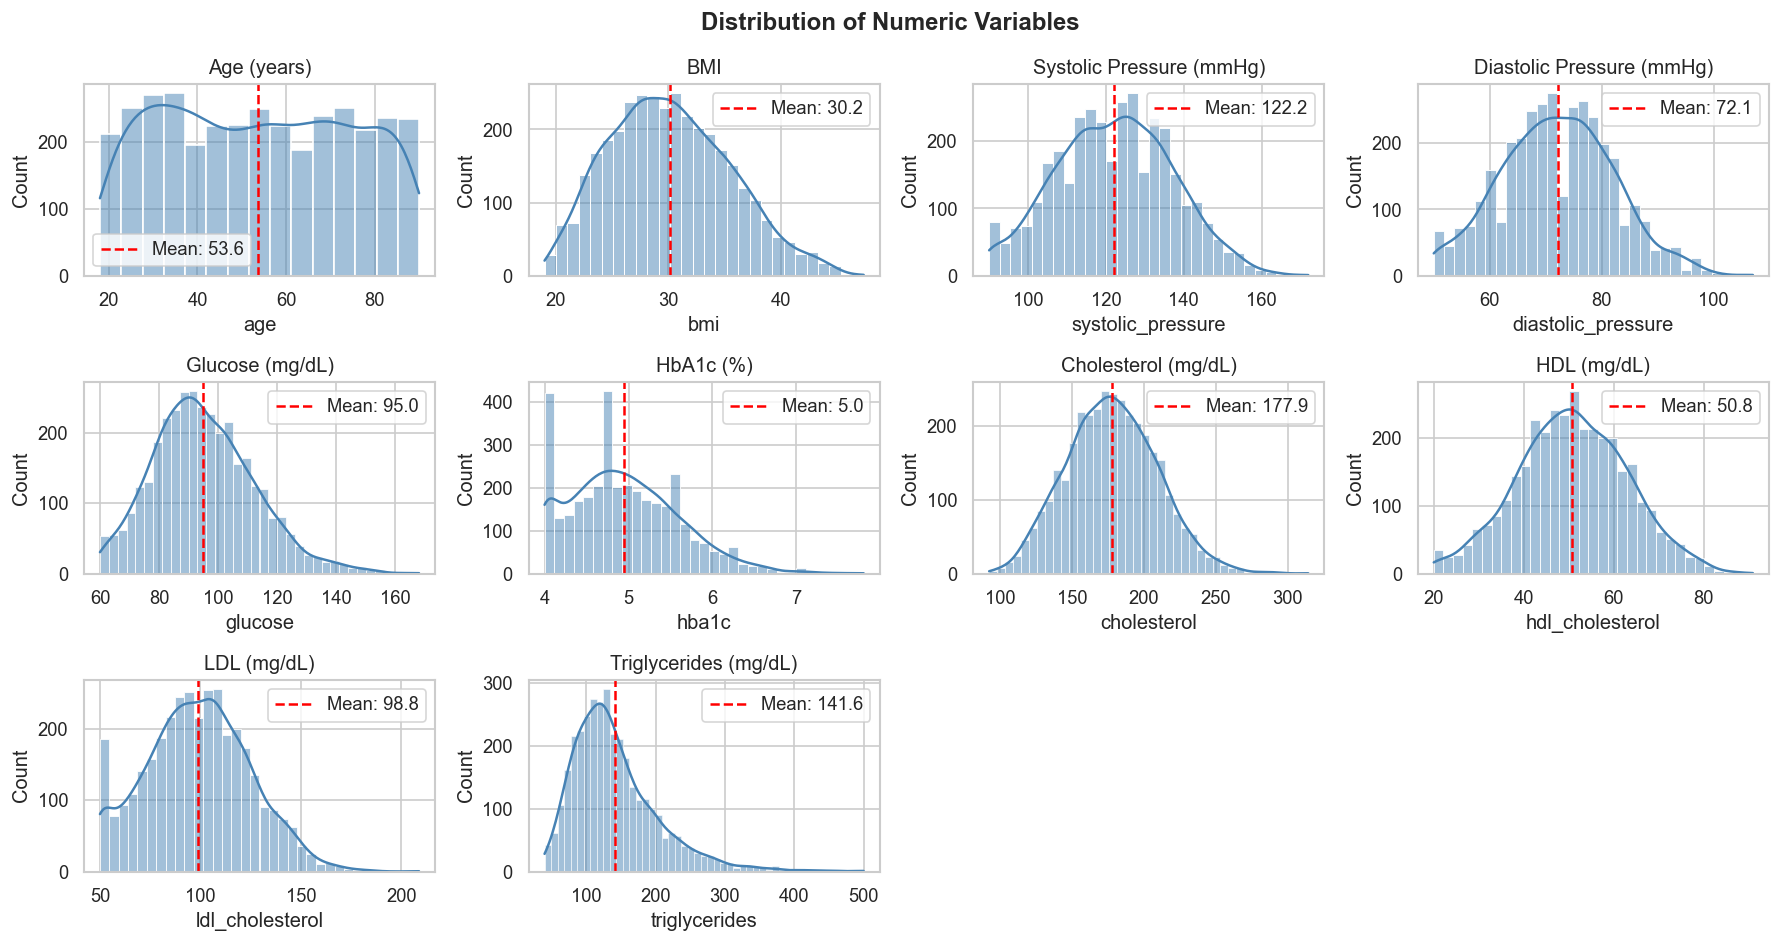

In [41]:
numeric_cols = ['age', 'bmi', 'systolic_pressure', 'diastolic_pressure', 'glucose',
                'hba1c', 'cholesterol', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides']

numeric_labels = ['Age (years)', 'BMI', 'Systolic Pressure (mmHg)', 'Diastolic Pressure (mmHg)',
                  'Glucose (mg/dL)', 'HbA1c (%)', 'Cholesterol (mg/dL)',
                  'HDL (mg/dL)', 'LDL (mg/dL)', 'Triglycerides (mg/dL)']

fig, axes = plt.subplots(3, 4, figsize=(15, 8))
axes = axes.flatten()

for i, (col, label) in enumerate(zip(numeric_cols, numeric_labels)):
    seaborn.histplot(df[col], kde=True, ax=axes[i], color='steelblue')
    
    mean_val = df[col].mean() #cals the mean of each graph
    
    axes[i].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.1f}')
    axes[i].set_title(label)
    axes[i].legend()

axes[-1].axis('off') #hide last spot since its only 5 graphs
axes[-2].axis('off') 
fig.suptitle('Distribution of Numeric Variables', fontweight='bold')
plt.tight_layout()
plt.show()

### Categorical and Ordinal Variables

Frequency counts for binary features (sex, smoking, family history) and the ordinal variable physical activity (0–7 days/week).

Important so we can know the lifestyle distribution of the dataset population

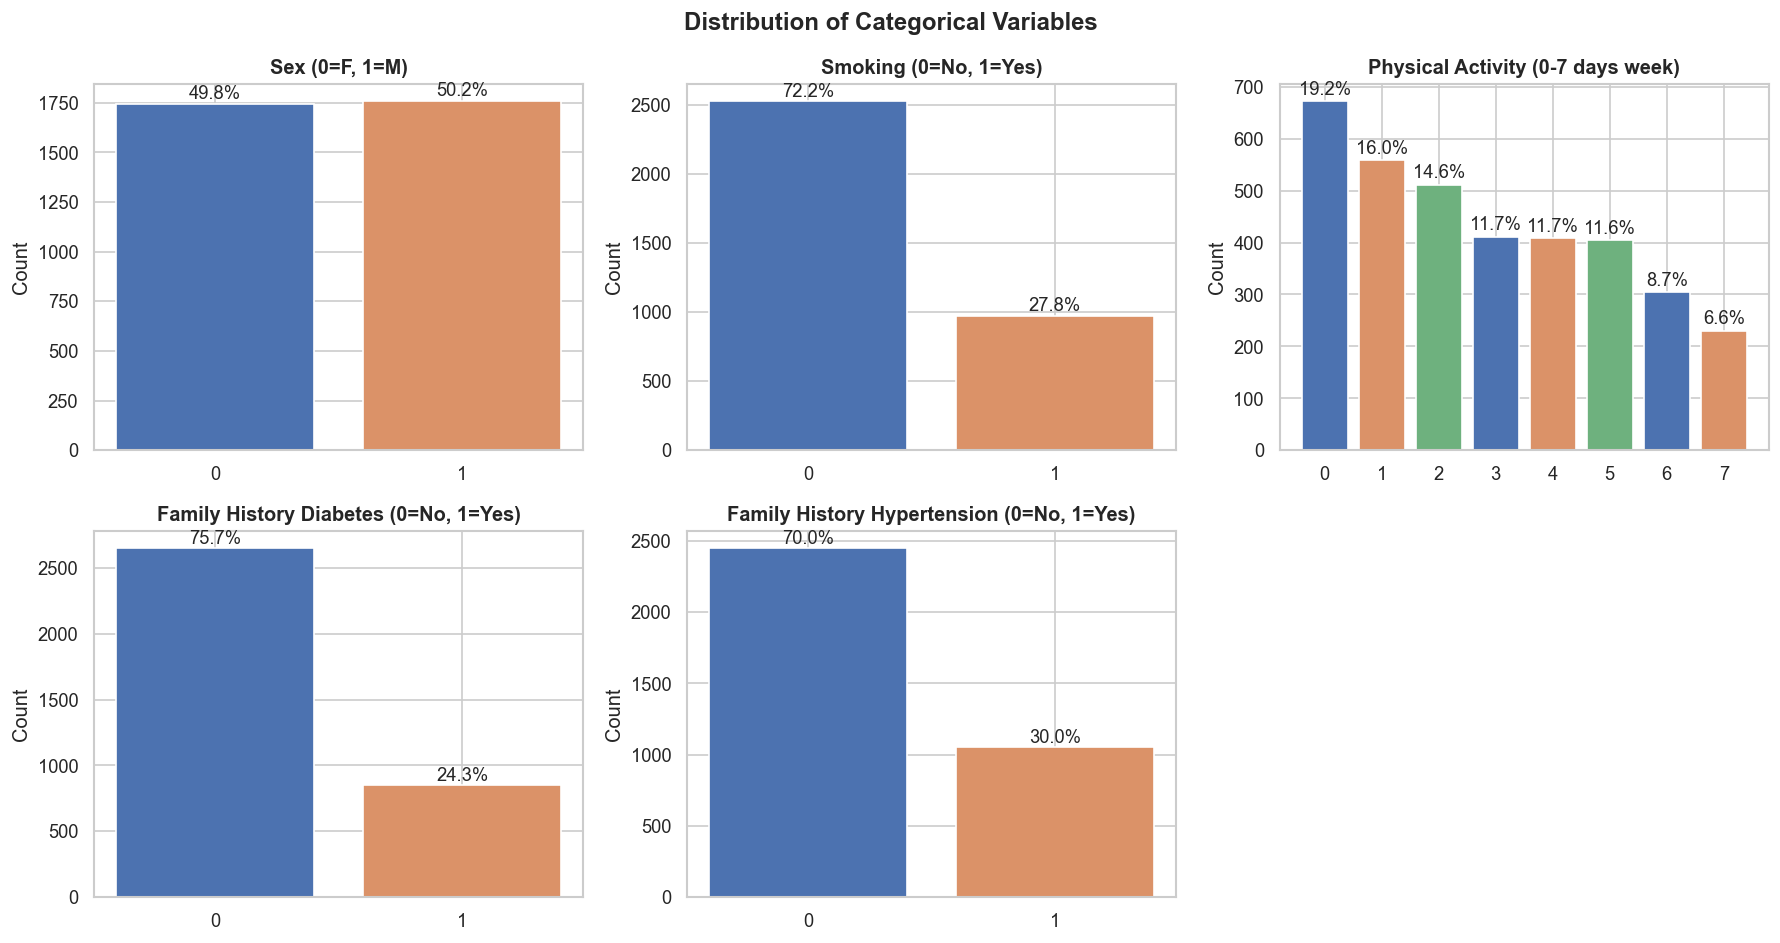

In [29]:
cat_cols = ['sex', 'smoking', 'physical_activity', 'family_history_diabetes', 'family_history_hypertension']
cat_labels = ['Sex (0=F, 1=M)', 'Smoking (0=No, 1=Yes)', 'Physical Activity (0-7 days week)',
              'Family History Diabetes (0=No, 1=Yes)', 'Family History Hypertension (0=No, 1=Yes)']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

colors = ['#4C72B0', "#DB9268", "#6EB17E"]

for i, (col, label) in enumerate(zip(cat_cols, cat_labels)):
    counts = df[col].value_counts().sort_index() #count how many times each value apears
    
    bars = axes[i].bar(counts.index.astype(str), counts.values, color=colors[:len(counts)])
    
    axes[i].set_title(label, fontweight='bold')
    axes[i].set_ylabel('Count')
    
    for bar in bars:
        height = bar.get_height()
        percentage = height / len(df) * 100
        
        axes[i].text(bar.get_x() + bar.get_width()/2, height + 5, f'{percentage:.1f}%',ha='center', va='bottom', fontsize=11)

axes[-1].axis('off')
fig.suptitle('Distribution of Categorical Variables', fontweight='bold')
plt.tight_layout()
plt.show()

## Balance

Check the balance of the dataset.

Important so we know if the target classes are balanced (according to real life) so the model can train with accurate data

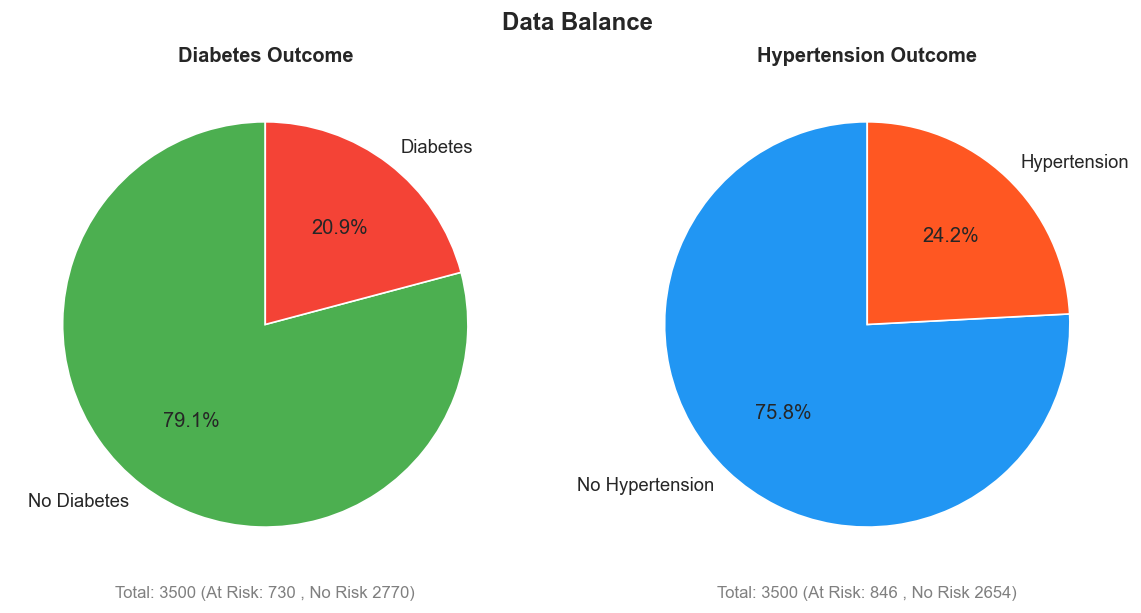

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

graph_labels = [
    ['No Diabetes', 'Diabetes'],
    ['No Hypertension', 'Hypertension']
]

for ax, col, title, colors, labels in zip(
    axes,
    ['diabetes_risk', 'hypertension_risk'],
    ['Diabetes Outcome', 'Hypertension Outcome'],
    [['#4CAF50', '#F44336'], ['#2196F3', '#FF5722']],
    graph_labels
):
    counts = df[col].value_counts().sort_index()
    wedges, texts, autotexts = ax.pie(
        counts.values,
        labels=labels,
        autopct='%1.1f%%',
        colors=colors,
        startangle=90,
    )
    
    ax.set_title(title, fontweight='bold')
   
    ax.text(0, -1.35, f'Total: {len(df)} (At Risk: {counts[1]} , No Risk {counts[0]})',
            ha='center', fontsize=10, color='grey')

fig.suptitle('Data Balance', fontweight='bold')
plt.tight_layout()
plt.show()

## Correlation Analysis

Analysis of the relationships between all variables helps identify which features are most predictive of each target and how the features relate with each other

### Correlation Heatmap
Overview of linear correlations between all numeric variables


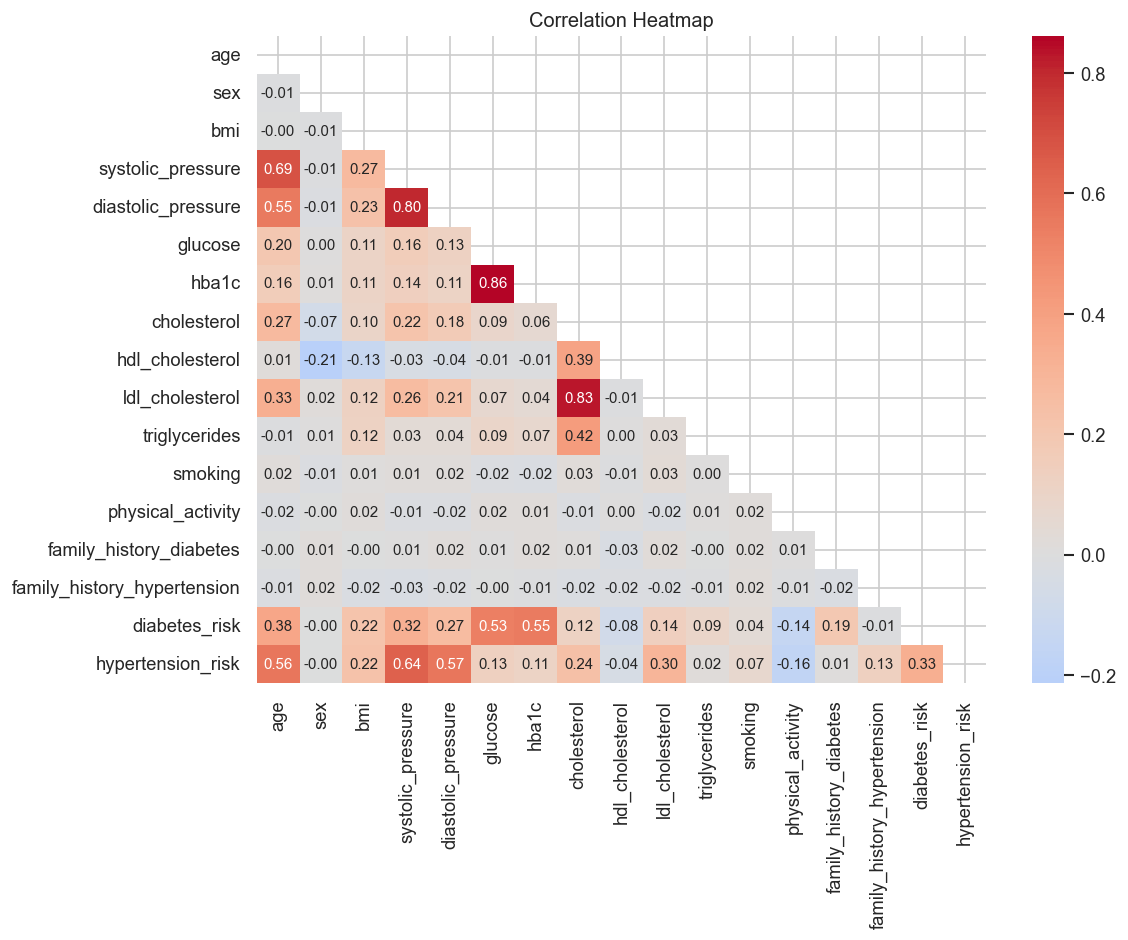

In [60]:
plt.figure(figsize=(10, 8))
corr = df.corr()
mask = numpy.triu(numpy.ones_like(corr, dtype=bool))
seaborn.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, annot_kws={'size': 9}) 

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()



## Feature Distributions by Target

Comparing feature distributions between patients with and without risk.

### Diabetes Risk
Compares the distribution of people with and without diabetes

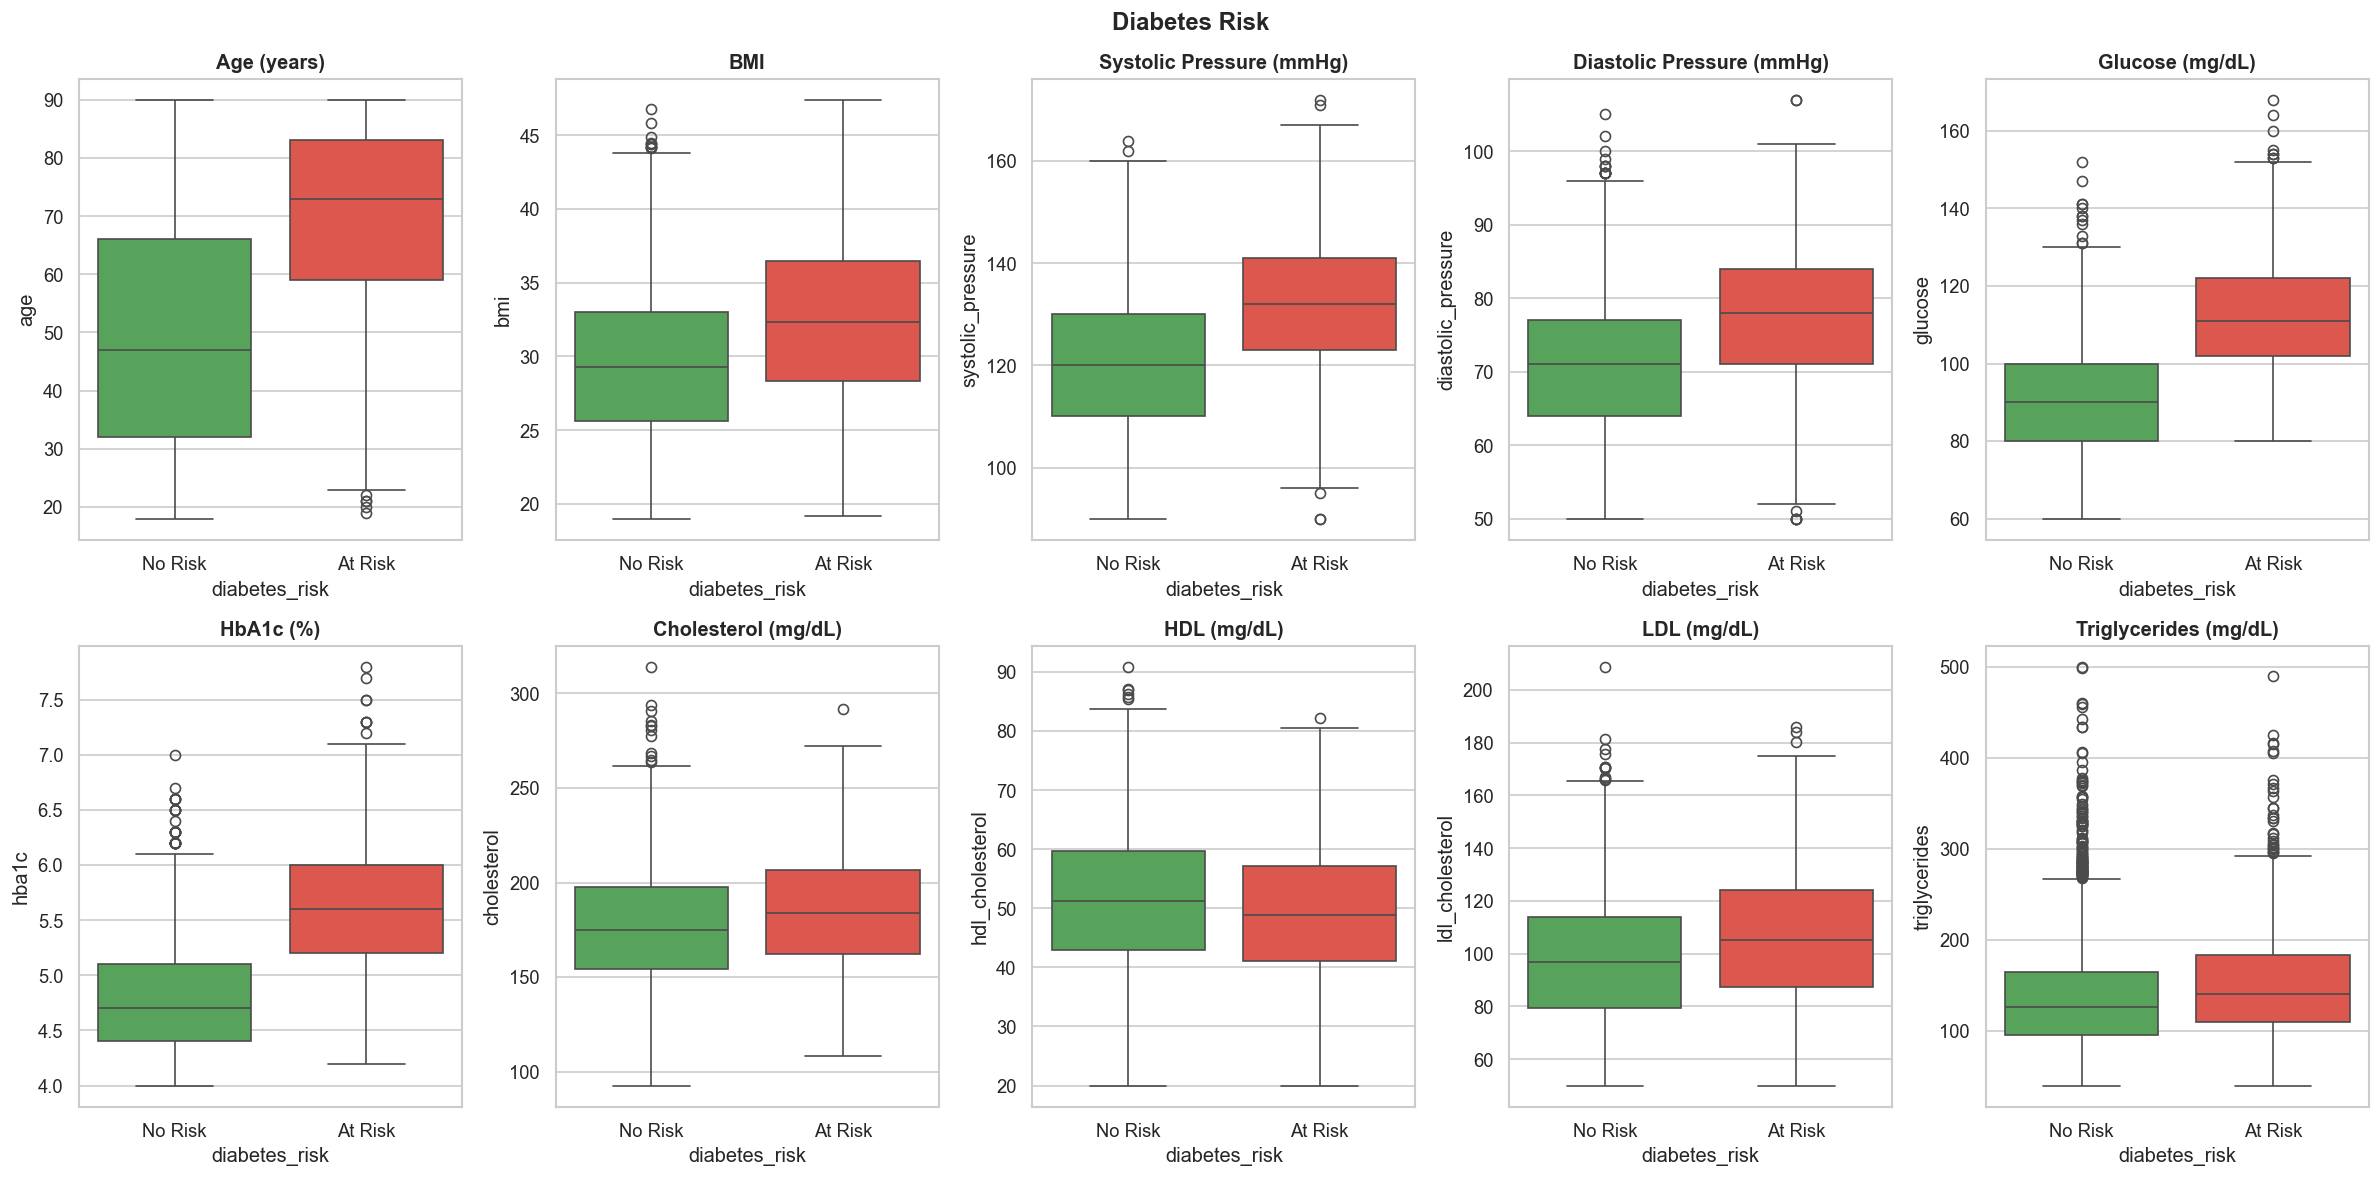

In [70]:
fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()

for ax, col, label in zip(axes, numeric_cols, numeric_labels):
    seaborn.boxplot(data=df, x='diabetes_risk', y=col, ax=ax,
                hue='diabetes_risk', palette=['#4CAF50', '#F44336'], legend=False)
    
    ax.set_title(label, fontweight='bold')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['No Risk', 'At Risk'])

fig.suptitle('Diabetes Risk', fontweight='bold')
plt.tight_layout()
plt.show()

### Hypertension Risk

Compares the distribution of people with and without hypertension


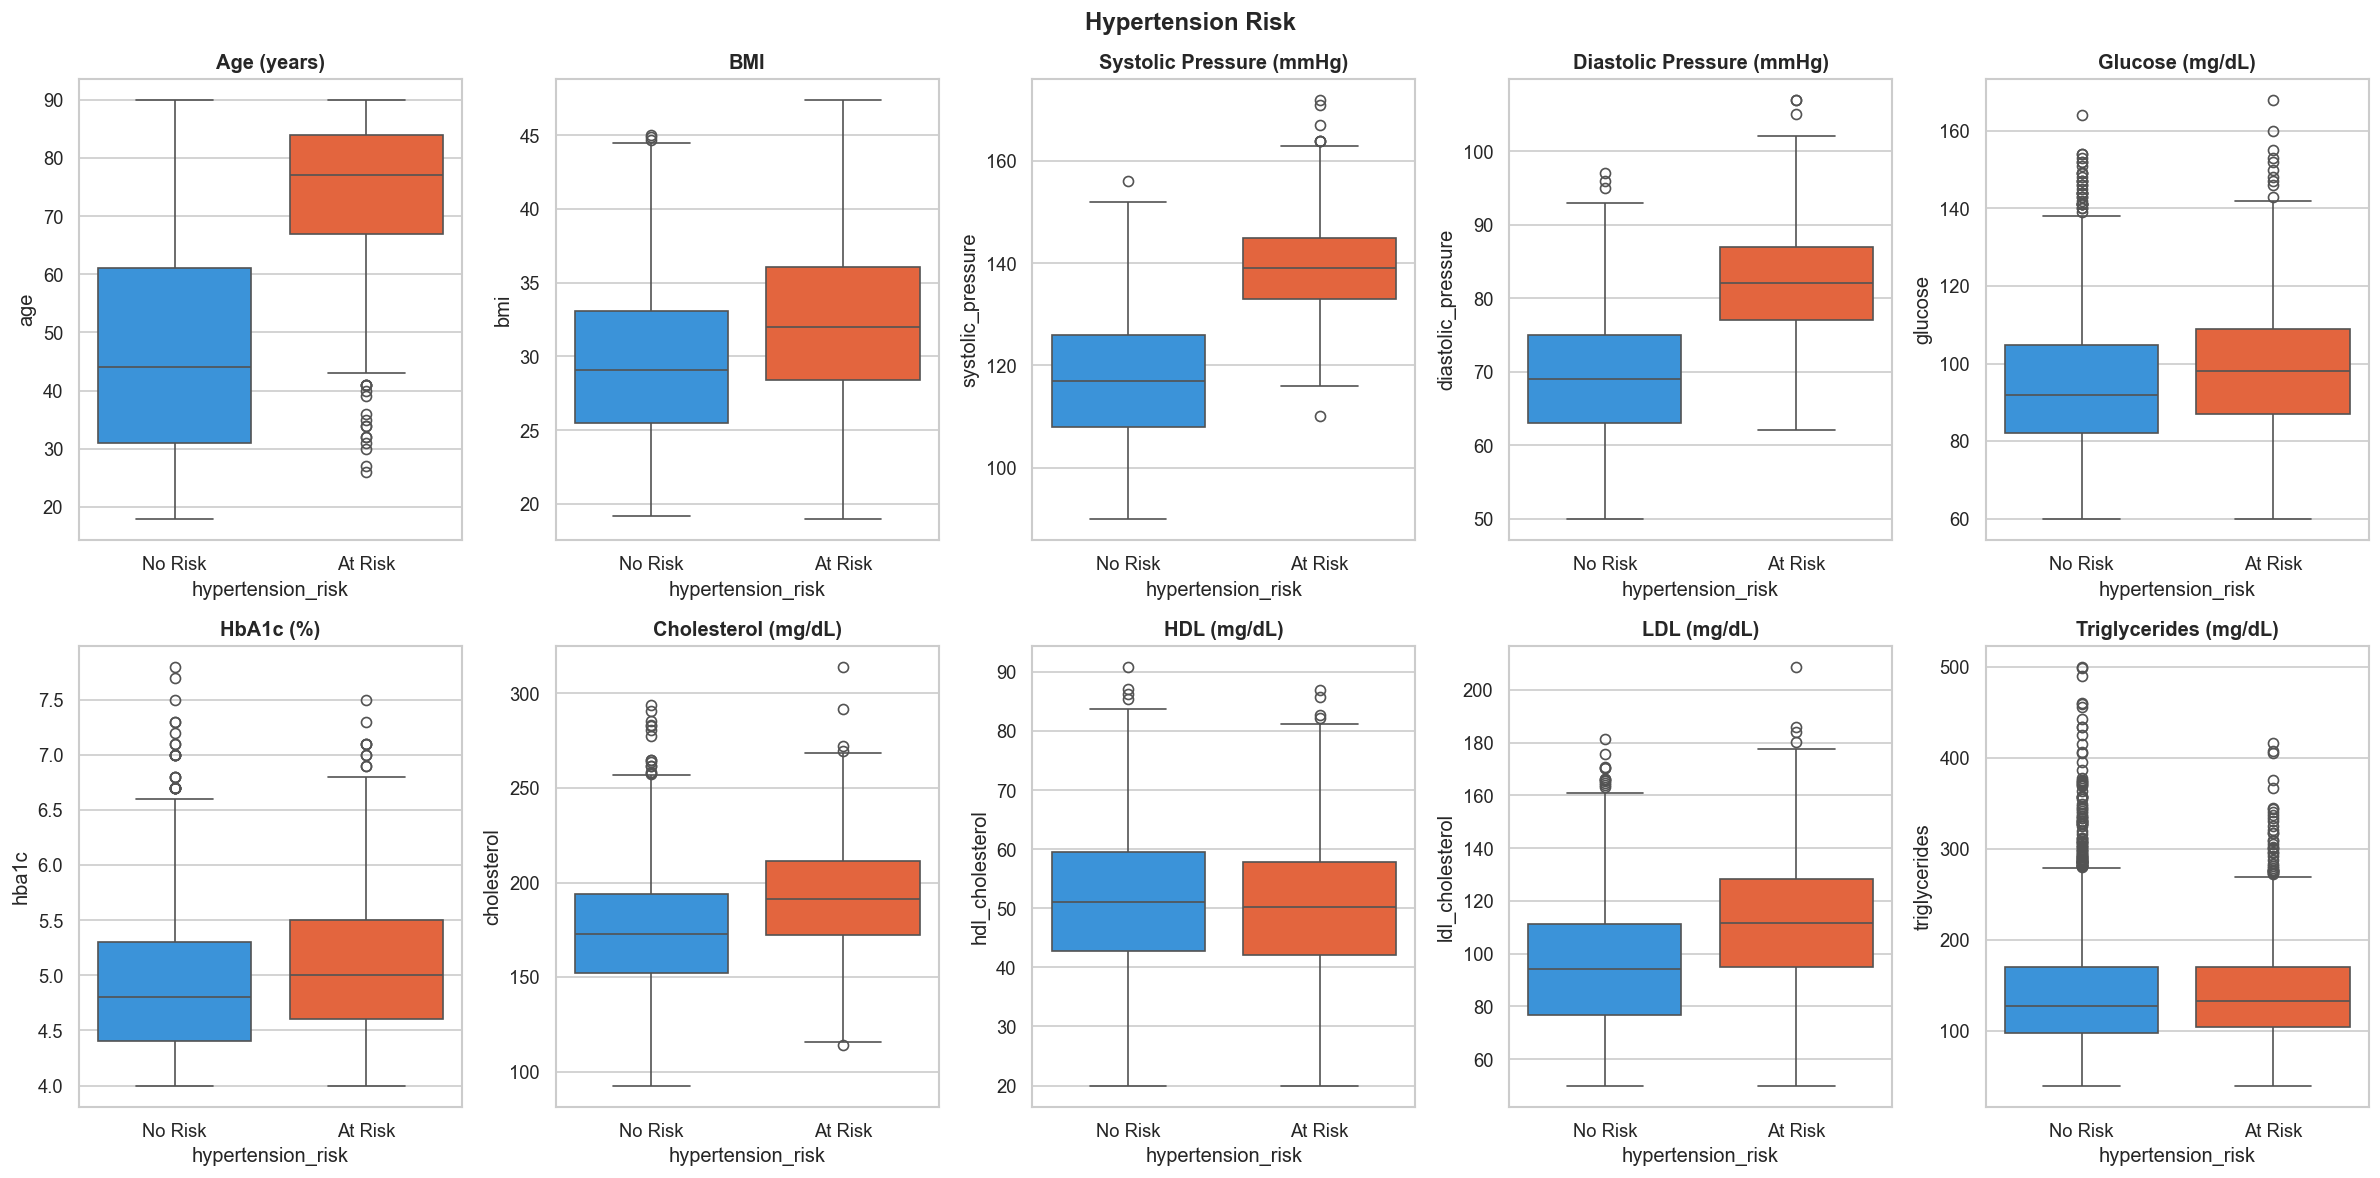

In [77]:
fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()

for ax, col, label in zip(axes, numeric_cols, numeric_labels):
    seaborn.boxplot(data=df, x='hypertension_risk', y=col, ax=ax,
                hue='hypertension_risk', palette=['#2196F3', '#FF5722'], legend=False)
    
    ax.set_title(label, fontweight='bold')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['No Risk', 'At Risk'])

fig.suptitle('Hypertension Risk', fontweight='bold')
plt.tight_layout()
plt.show()

### Feature Correlation with Each Target

Bar chart showing which features are most correlated with each risk.

Positive bars indicate risk factors (higher value means higher risk) and negative bars indicate protective factors ("higher" value means lower risk).



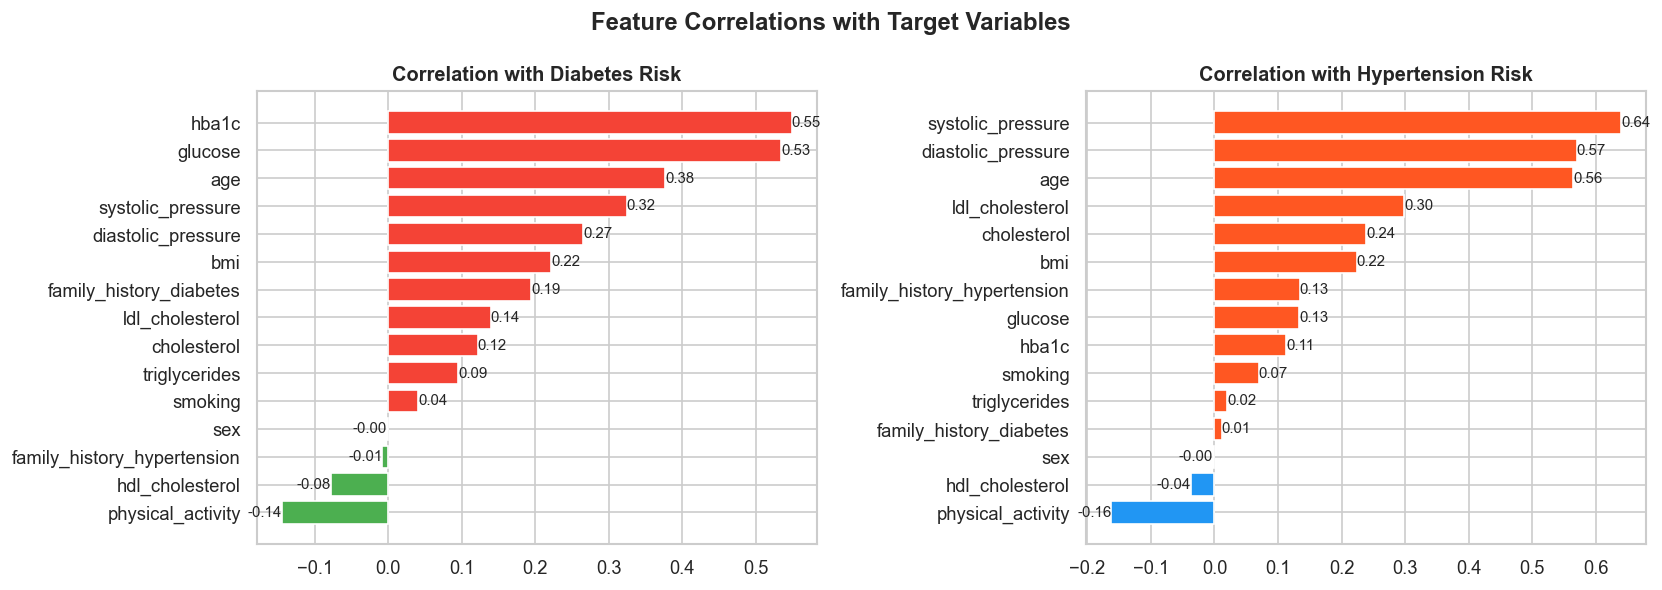

In [ ]:
features = ['age', 'sex', 'bmi', 'systolic_pressure', 'diastolic_pressure','glucose', 'hba1c', 
            'cholesterol', 'hdl_cholesterol', 'ldl_cholesterol','triglycerides', 'smoking', 
            'physical_activity','family_history_diabetes', 'family_history_hypertension']

correlation_diabetes = df[features + ['diabetes_risk']].corr()['diabetes_risk'][features].sort_values()
correlation_hypert = df[features + ['hypertension_risk']].corr()['hypertension_risk'][features].sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, correlation_vals, title, color_positive, color_negative in zip(
    axes,[correlation_diabetes, correlation_hypert],
    ['Correlation with Diabetes Risk', 'Correlation with Hypertension Risk'],
    ['#F44336', '#FF5722'], ['#4CAF50', '#2196F3']
):
    colors = []
    for values in correlation_vals:
        if values > 0:
            colors.append(color_positive)
        else:
            colors.append(color_negative)
    
    bars = ax.barh(correlation_vals.index, correlation_vals.values, color=colors)
    ax.set_title(title, fontweight='bold')
    
    for bar, val in zip(bars, correlation_vals.values):
        ax.text(val, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', 
                ha='left' if val >= 0 else 'right', fontsize=9)

fig.suptitle('Feature Correlations with Target Variables', fontweight='bold')
plt.tight_layout()
plt.show()